In [ ]:
!pip install scpviz[sc]

In [1]:
from scpviz import pAnnData as pAnnData
from scpviz import plotting as scplt
from scpviz import utils as scutils
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='paper', style='ticks')

# Single Cell

This tutorial demonstrates a typical analysis workflow for **single-cell proteomics data** using `scpviz`. Single-cell proteomic datasets are generally more sparse and contain higher levels of missing values than bulk proteomics, requiring careful preprocessing, normalization, and interpretation. Here we illustrate common steps including dataset filtering, handling missing values, normalization, dimensionality reduction, differential expression analysis, and integration with external single-cell tools such as **scanpy**.

The workflow presented here reflects the authors' current approach in the rapidly developing field of single-cell proteomics. Several recent reviews discuss best practices and analytical considerations for these datasets, including those by Gatto et al. (2023), Vanderaa and Gatto (2023), and Wang et al. (2025). Because the field is evolving quickly, analytical approaches continue to develop and may vary depending on experimental design and data characteristics.

**Recommended references**

- [Gatto L. et al. (2023). *Initial recommendations for performing, benchmarking and reporting single-cell proteomics experiments.* Nature Methods.](https://www.nature.com/articles/s41592-023-01785-3)

- [Vanderaa C. & Gatto L. (2023). *Revisiting the Thorny Issue of Missing Values in Single-Cell Proteomics.* Journal of Proteome Research.](https://doi.org/10.1021/acs.jproteome.3c00227)

- [Wang S. et al. (2025). *Benchmarking informatics workflows for data-independent acquisition single-cell proteomics.* Nature Communications.](https://www.nature.com/articles/s41467-025-65174-4)

In this tutorial we use a small example dataset derived from our recent preprint ([Sayan and Pang et al. 2025](https://doi.org/10.1101/2025.02.10.637505)). The dataset contains **single-cell proteomic measurements of astrocytes**, comparing injured versus uninjured cells.


In [ ]:
!wget -q https://github.com/gnaprs/scpviz/raw/main/docs/assets/report_sc.parquet

We begin by loading the dataset into a `pAnnData` object.

In [2]:
obs_columns = ['date', 'acquisition', 'size', 'cell_type', 'replicate']

pdata_sc = pAnnData.import_data(source_type='diann', report_file = 'report_sc.parquet', obs_columns=obs_columns)
# pdata_sc = pAnnData.import_data(source_type='diann', report_file = '../assets/report_sc.parquet', obs_columns=obs_columns)

🧭 [USER] Importing data of type [diann]
--------------------------
Starting import [DIA-NN]

Source file: ../assets/report_sc.parquet
Number of files: 20
Proteins: 8678
Peptides: 69299

     ℹ️ [INFO] Using sample-specific q-values for 'prot' significance annotation.
     ℹ️ [INFO] Using sample-specific q-values for 'pep' significance annotation.

ℹ️ RS matrix: (8678, 69299) (proteins × peptides), sparsity: 99.99%
   - Proteins with ≥2 *unique* linked peptides: 4452/8678
   - Peptides linked to ≥2 proteins: 9794/69299
   - Mean peptides per protein: 9.63
   - Mean proteins per peptide: 1.21
     ✅ [OK] pAnnData object is valid.
     ✅ [OK] Import complete. Use `print(pdata)` to view the object.
--------------------------


The `.summary` table contains sample-level metadata and quality metrics such as protein counts, peptide counts, and intensity statistics. We can inspect the dataset by looking at the sample summary table:

In [3]:
import pandas as pd
pd.DataFrame(pdata_sc.summary)

,date,acquisition,size,cell_type,replicate,protein_quant,protein_count,protein_abundance_sum,peptide_quant,peptide_count,peptide_abundance_sum,unique_pep2_protein_count
20240418_Aur60minDIA_10k_T2_01,20240418,Aur60minDIA,10k,T2,01,0.715718,6211,7.335632e+08,0.566430,39253,2.950953e+09,3867
20240418_Aur60minDIA_10k_T2_02,20240418,Aur60minDIA,10k,T2,02,0.632634,5490,9.521519e+08,0.467886,32424,3.253213e+09,3602
20240418_Aur60minDIA_10k_TEAB35_02,20240418,Aur60minDIA,10k,TEAB35,02,0.662826,5752,1.275570e+09,0.472128,32718,3.940106e+09,3634
20240418_Aur60minDIA_20k_T2_03,20240418,Aur60minDIA,20k,T2,03,0.758700,6584,7.323146e+08,0.640817,44408,3.042173e+09,3999
20240418_Aur60minDIA_20k_TEAB35_01,20240418,Aur60minDIA,20k,TEAB35,01,0.659138,5720,8.297490e+08,0.476313,33008,3.092659e+09,3675
20240418_Aur60minDIA_20k_TEAB35_03,20240418,Aur60minDIA,20k,TEAB35,03,0.763425,6625,6.757145e+08,0.606733,42046,2.709277e+09,3984
20240425_Aur60minDIA_5k_TEAB35_01,20240425,Aur60minDIA,5k,TEAB35,01,0.421641,3659,2.646704e+09,0.206612,14318,9.309179e+09,2583
20240425_Aur60minDIA_10k2_T2_01,20240425,Aur60minDIA,10k2,T2,01,0.799954,6942,7.020355e+08,0.695479,48196,2.755400e+09,4054
20240601_Aur60minDIA_S12_astrocyte_J11,20240601,Aur60minDIA,S12,astrocyte,J11,0.248329,2155,6.067614e+09,0.102988,7137,1.741655e+10,1597
20240601_Aur60minDIA_S12_astrocyte_J12,20240601,Aur60minDIA,S12,astrocyte,J12,0.456672,3963,1.894990e+09,0.250004,17325,5.329589e+09,2738


Here, the metadata column `cell_type` indicates whether each single-cell measurement corresponds to an **astrocyte** or **neuronal** cell. Additional columns in the summary include quality metrics such as protein counts, peptide counts, and intensity statistics for each sample.

## Preprocessing and normalization for single-cell proteomics

Below is the authors' current preprocessing workflow used in this tutorial. The steps are organized to progressively clean the dataset before performing normalization and downstream analysis.


### Filter to single-cell samples and define conditions

First, we restrict the dataset to the **astrocyte single-cell samples** of interest and remove the bulk-like control injections (`T2` and `TEAB35`). We then remap the original `cell_type` labels into a cleaner `condition` column for downstream analysis.

In [4]:
pdata_sc_filtered = pdata_sc.filter_sample(condition="cell_type not in ['T2','TEAB35']")

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: cell_type not in ['T2','TEAB35']
     ℹ️ Auto-cleanup: Removed 3228 empty proteins (all-NaN or all-zero). Proteins: O35226-4, E9Q4N7, Q6PD26, Q91ZP6, Q8R3H9, P97868, P97868-2, Q3U1F9, Q8C196, P46662, ...
    → Samples kept: 11, Samples dropped: 9
    → Proteins kept: 5450



Next, we remap the labels so that the two biological conditions are easier to interpret.

In [5]:
mapping = {
    "scartissue": "SWI",
    "astrocyte": "Uninjured",
}

pdata_sc_filtered.summary["condition"] = (pdata_sc_filtered.summary["cell_type"].replace(mapping))

pdata_sc_filtered.update_summary()

🔄 [UPDATE] Updating summary [sync_back]: pushed edits from `.summary` to `.obs` (marked stale).
      Columns updated: condition.


# Preprocessing (general quality control)

The next steps perform **general preprocessing** to remove low-confidence proteins and low-quality samples.

### Filter proteins by significance (FDR)

First, we filter proteins using the default **q-value / FDR cutoff** (default: 0.01).

In [6]:
pdata_sc_filtered = pdata_sc_filtered.filter_prot_significant()

🧭 [USER] Filtering proteins [Significance|File-mode]:
     ℹ️ [INFO] No group provided. Defaulting to sample-level significance filtering.
    Returning a copy of protein data based on significance thresholds:
     🔸 Files requested: All
     🔸 FDR threshold: 0.01
     🔸 Logic: any (protein must be significant in ≥1 file(s))
    → Proteins kept: 4637, Proteins dropped: 813
     ✅ [OK] RS matrix filtered: 4637 proteins, 59894 peptides retained.



### Filter samples by minimum protein count

Next, we remove samples with very low protein coverage as a simple **quality control step**.

In [7]:
pdata_sc_filtered = pdata_sc_filtered.filter_sample(min_prot=1000)

🧭 [USER] Filtering samples [condition]:
    Returning a copy of sample data based on condition:
     🔸 Condition: protein_count >= 1000
     ℹ️ Auto-cleanup: No empty proteins found (all-NaN or all-zero).
    → Samples kept: 10, Samples dropped: 1
    → Proteins kept: 4637



### Filter valid genes and duplicated abundance profiles

We then filter proteins using two additional criteria:

- **valid_genes** – proteins must be associated with a valid gene name. Entries without gene annotations are removed.
- **unique_profiles** – if isoforms are not distinguished by unique peptides, they can appear with identical abundance profiles. This is common in single-cell datasets because of missing peptide measurements. These redundant profiles are removed.


In [8]:
pdata_sc_filtered = pdata_sc_filtered.filter_prot(
    valid_genes=True,
    unique_profiles=True,
)

🧭 [USER] Filtering proteins [valid genes, unique profiles]:
    Returning a copy of protein data with the following filters applied:
     🔸 valid_genes — removed 25 proteins with invalid gene names
     🔸 valid_genes — resolved 576 duplicate gene names by appending numeric suffixes
     🔸 unique_profiles — removed 801 duplicate and 0 empty abundance profiles (801 total)
    → Proteins kept: 3811
    → Peptides kept (linked): 59848
     ✅ [OK] RS matrix filtered: 3811 proteins, 59848 peptides retained.


# Preprocessing (specific usage)

The above steps perform general cleanup. For **biological comparison**, it may help to apply additional filtering to increase confidence in downstream analyses.

### Filter proteins based on presence within groups

Single-cell datasets contain many missing values. A common approach is to retain proteins that are present in a minimum fraction of cells within the biological groups of interest.

Here we require proteins to be present in **at least 40% of cells in each `condition`** (`Uninjured` or `SWI`).

In [9]:
pdata_sc_processed = pdata_sc_filtered.filter_prot_found(
    min_ratio=0.4,
    group=["condition"],
    match_any=True,
)

🧭 [USER] Filtering proteins [Found|Group-mode|ANY]:
     ℹ️ [INFO] Found matching groups(s): ['Uninjured', 'SWI']. Automatically annotating detection by group values.
    Returning a copy of protein data based on detection thresholds:
     🔸 Groups requested: ['Uninjured', 'SWI']
     🔸 Minimum ratio: 0.4
     🔸 Logic: any (protein must be detected in ≥1 group(s))
    → Proteins kept: 3192, Proteins dropped: 619
     ✅ [OK] RS matrix filtered: 3192 proteins, 56641 peptides retained.



# Normalization for single-cell data

After preprocessing, we normalize the dataset for downstream analysis.

### Recommended: DirectLFQ normalization

For single-cell proteomics data, **DirectLFQ normalization** is often a strong default ([`directlfq`](https://doi.org/10.1016/j.mcpro.2023.100581)). `scpviz` supports DirectLFQ with the following keyword arguments:
- `input_type_to_use` (str): For `'directlfq'`, specify `'pAnnData'` (default, passing through a `pAnnData` object), `'diann_precursor_ms1'`, or `'diann_precursor_ms1_and_ms2'`.
- `path` (str): For `'directlfq'`, the path to the DIA-NN report.tsv or report.parquet output file.
- `strict` (bool): For `'directlfq'`, whether to use only unique peptides (True) or unique + shared peptides (False, default).

See the [API reference](https://gnaprs.github.io/scpviz/reference/pAnnData/analysis_mixin/#src.scpviz.pAnnData.analysis.AnalysisMixin.normalize) for more details on normalization options.


In [10]:
pdata_sc_norm = pdata_sc_processed.copy()
pdata_sc_norm.normalize(method="directlfq")

🧭 [USER] Running directlfq normalization on peptide-level data.
     ℹ️ Note: please be patient, directlfq can take a minute to run depending on data size. Output files will be produced.
     ℹ️ [INFO] Expanded multi-protein peptide groups: 56641 → 66848 rows.


2026-06-22 00:48:07,591 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2026-06-22 00:48:07,973 - directlfq.lfq_manager - INFO - Performing sample normalization.
2026-06-22 00:48:10,635 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2026-06-22 00:48:10,640 - directlfq.protein_intensity_estimation - INFO - 3192 lfq-groups total
2026-06-22 00:48:12,569 - directlfq.protein_intensity_estimation - INFO - using 12 processes
2026-06-22 00:48:26,645 - directlfq.lfq_manager - INFO - Could not add additional columns to protein table, printing without additional columns.
2026-06-22 00:48:26,646 - directlfq.lfq_manager - INFO - Writing results files.
2026-06-22 00:48:26,986 - directlfq.lfq_manager - INFO - Analysis finished!


     ℹ️ Set protein data to layer X_norm_directlfq.
     ✅ directlfq normalization complete. Results are stored in layer 'X_norm_directlfq'.
          ⚠️ Downstream imputation should be performed with the flag `use_zeros_as_nan` set to True due to directlfq output format returning NaNs as 0s.


!!! note
    The directLFQ algorithm will create files in the workspace. Running directLFQ multiple times will overwrite these files. If you want to keep the output files, consider copying them to a different location before running directLFQ again.

### Alternative approach used in some workflows

Some workflows normalize using the **median of fully observed proteins**. This approach uses only proteins that have abundance values in every sample.

`scpviz` supports this using the `use_nonmissing=True` option. The `force=True` flag is required to override the default behavior of normalizing only if all samples have less than 50% missing values, which is likely for single-cell data.

In [12]:
pdata_sc_norm = pdata_sc_processed.copy()

pdata_sc_norm.normalize(
    method="median",
    use_nonmissing=True,
    force=True,
)

🧭 [USER] Global normalization using 'median' (using only fully observed columns). Layer will be saved as 'X_norm_median'.
     ⚠️ [WARN] 1 sample(s) have >50% missing values.
     Try running `.impute()` before normalization. Suggest to use the flag `use_nonmissing=True` to normalize using only consistently observed proteins.
     ⚠️ [WARN] Proceeding with normalization despite bad rows (force=True).
     ℹ️ Normalizing using only fully observed columns: 872
     ✅ Normalized all 10 samples.
     ℹ️ Set protein data to layer X_norm_median.


### Imputation

Imputation for single-cell proteomics data is often more challenging than for bulk datasets because missing values are much more common and can reflect both technical sparsity and biological signal. For this reason, imputation should be applied carefully and with the downstream analysis in mind.

A common conservative approach is **minimum-value imputation**, where missing values are replaced with a small value scaled relative to the observed minimum.

In [ ]:
pdata_sc_norm.impute(method="min", min_scale=0.2)

🧭 [USER] Global imputation using 'min'. Layer saved as 'X_impute_min'. Minimum scaled by 0.2.
     ✅ 10384 values imputed.
     ℹ️ 10 samples fully imputed, 0 samples partially imputed, 0 skipped feature(s) with all missing values.
     ℹ️ Set protein data to layer X_impute_min.


Another recommendation is to use the **PIMMS** algorithm (**Proteomics Imputation Modeling Mass Spectrometry**), which was developed specifically for proteomics data imputation. For more information, see the [package](https://github.com/RasmussenLab/pimms) or the [manuscript](https://www.nature.com/articles/s41467-024-48711-5#Fig1).

In `scpviz`, this can be run using:

In [ ]:
pdata_sc_norm.impute(method="pimms_dae")

!!! note
    The `pimms` package may currently be difficult to install in some environments because of pip dependency resolver issues. If installation fails, minimum-value imputation remains a reasonable fallback for exploratory single-cell analysis.

## Visualization

After preprocessing and normalization, we can begin exploring the single-cell dataset visually. Below are a few useful ways to examine sample quality, overlap between conditions, and low-dimensional structure.

First, we define a color palette for the conditions:


In [11]:
condition_color={
    "SWI": "#1F98B1",
    "Uninjured": "#84C8D5" # "#CAEEFB"
}

### QC and Venn diagrams

#### Protein count
Comparing protein counts across conditions provides a quick quality-control view of depth and variability.

C:\Users\srpang\AppData\Local\Temp\ipykernel_20348\3694285531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


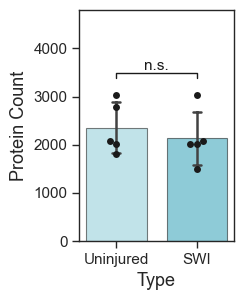

In [12]:
fig, ax = plt.subplots(figsize=(2, 3))

dataset = pdata_sc_filtered
order = ['Uninjured', 'SWI']

sns.barplot(
    x="condition",
    y="protein_count",
    data=dataset.summary,
    errorbar="sd",
    capsize=.1,
    saturation=1,
    alpha=0.5,
    palette=condition_color,
    width=0.75,
    order=order,
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
)
sns.swarmplot(
    x="condition",
    y="protein_count",
    data=dataset.summary,
    order=order,
    color="k",
    ax=ax,
)

from scipy.stats import ttest_ind

statsUninjured = dataset.summary[
    dataset.summary["condition"] == "Uninjured"
]["protein_count"]
statsSWI = dataset.summary[
    dataset.summary["condition"] == "SWI"
]["protein_count"]

max_prot_count = dataset.summary["protein_count"].max()

scplt.plot_significance(
    ax,
    max_prot_count + 350,
    100,
    pval=ttest_ind(statsUninjured, statsSWI).pvalue,
    fontsize=11,
)

plt.ylabel("Protein Count", fontsize=13, labelpad=4)
plt.xlabel("Type", fontsize=13, labelpad=4)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
plt.ylim(0, 4800)
plt.show()

#### Venn diagram

A Venn diagram provides a simple view of proteins unique to each condition and those shared between them. We can also extract the lists of proteins in each category by accessing the returned venn_contents.

Classes: condition, Values: Uninjured
Filter query: ((adata.obs['condition'] == 'Uninjured'))
Classes: condition, Values: SWI
Filter query: ((adata.obs['condition'] == 'SWI'))


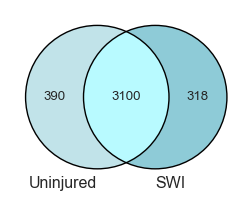

In [13]:
fig, ax = plt.subplots(figsize=(3, 3))
ax, venn_contents = scplt.plot_venn(
    ax,
    dataset,
    classes="condition",
    set_colors=["#84C8D5", "#1F98B1"],
    return_contents=True,
)
plt.rcParams.update({"font.size": 12})  # run twice if font size does not update
plt.show()

setUninjured = set(venn_contents["Uninjured"])
setSWI = set(venn_contents["SWI"])
venn_df = pd.DataFrame({
    "Unijured_only": pd.Series(sorted(setUninjured - setSWI)),
    "SWI_only": pd.Series(sorted(setSWI - setUninjured)),
    "Both": pd.Series(sorted(setSWI & setUninjured)),
})

#### Protein Abundance

We can also directly visualize the abundance of specific proteins across conditions.  
The helper function `plot_abundance_boxgrid()` provides a convenient way to display violin/box/bar-style abundance plots with sample-level points.

If you want to access the underlying data directly, `.get_abundance()` returns a dataframe containing the abundance values.

In [14]:
abundance_itgam_cd68 = pdata_sc_norm.get_abundance(
    namelist=["Itgam", "Cd68"],
    classes="condition",
)

abundance_itgam_cd68

,cell,accession,abundance,index,date,acquisition,size,cell_type,replicate,protein_quant,protein_count,protein_abundance_sum,condition,gene,x_label_name,class,log2_abundance
0,20240601_Aur60minDIA_S12_astrocyte_J11,P05555,0.000000e+00,20240601_Aur60minDIA_S12_astrocyte_J11,20240601,Aur60minDIA,S12,astrocyte,J11,0.565476,1805,4.431239e+09,Uninjured,Itgam,Itgam,Uninjured,-19.931569
1,20240601_Aur60minDIA_S12_astrocyte_J12,P05555,0.000000e+00,20240601_Aur60minDIA_S12_astrocyte_J12,20240601,Aur60minDIA,S12,astrocyte,J12,0.883145,2819,1.446993e+09,Uninjured,Itgam,Itgam,Uninjured,-19.931569
2,20240601_Aur60minDIA_S12_astrocyte_J10,P05555,0.000000e+00,20240601_Aur60minDIA_S12_astrocyte_J10,20240601,Aur60minDIA,S12,astrocyte,J10,0.644110,2056,1.910754e+09,Uninjured,Itgam,Itgam,Uninjured,-19.931569
3,20240601_Aur60minDIA_S12_astrocyte_J15,P05555,0.000000e+00,20240601_Aur60minDIA_S12_astrocyte_J15,20240601,Aur60minDIA,S12,astrocyte,J15,0.834586,2664,4.280814e+09,Uninjured,Itgam,Itgam,Uninjured,-19.931569
4,20240601_Aur60minDIA_S12_scartissue_K10,P05555,1.257059e+06,20240601_Aur60minDIA_S12_scartissue_K10,20240601,Aur60minDIA,S12,scartissue,K10,0.618108,1973,3.160946e+09,SWI,Itgam,Itgam,SWI,20.261621
5,20240601_Aur60minDIA_S12_scartissue_K14,P05555,7.408469e+05,20240601_Aur60minDIA_S12_scartissue_K14,20240601,Aur60minDIA,S12,scartissue,K14,0.856830,2735,1.015376e+09,SWI,Itgam,Itgam,SWI,19.498816
6,20240601_Aur60minDIA_S12_scartissue_K15,P05555,1.494039e+06,20240601_Aur60minDIA_S12_scartissue_K15,20240601,Aur60minDIA,S12,scartissue,K15,0.618734,1975,2.388097e+09,SWI,Itgam,Itgam,SWI,20.510786
7,20240601_Aur60minDIA_S12_scartissue_K12,P05555,4.416432e+05,20240601_Aur60minDIA_S12_scartissue_K12,20240601,Aur60minDIA,S12,scartissue,K12,0.642857,2052,2.366926e+09,SWI,Itgam,Itgam,SWI,18.752522
8,20240601_Aur60minDIA_S12_astrocyte_J14,P05555,6.880741e+05,20240601_Aur60minDIA_S12_astrocyte_J14,20240601,Aur60minDIA,S12,astrocyte,J14,0.616228,1967,1.642195e+09,Uninjured,Itgam,Itgam,Uninjured,19.392205
9,20240601_Aur60minDIA_S12_scartissue_K11,P05555,1.532388e+06,20240601_Aur60minDIA_S12_scartissue_K11,20240601,Aur60minDIA,S12,scartissue,K11,0.466792,1490,1.743475e+09,SWI,Itgam,Itgam,SWI,20.547350


c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

     ⚠️ [WARN] Cd68: group 'Uninjured' has no detectable abundance ('ND').


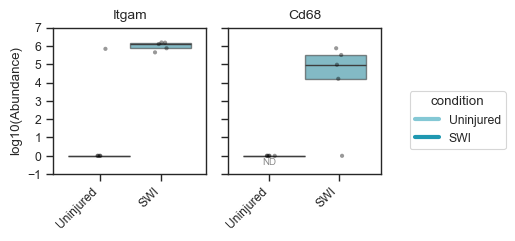

In [12]:
# showing in log10 y axis scale

text_kwargs = dict(
    fontsize=11,
    color="black",
    offset=1,
)

figsize = (2, 2.5)

fig, ax = pdata_sc_norm.plot_abundance_boxgrid(
    namelist=["Itgam", "Cd68"],
    classes="condition",
    plot_type="box",
    log_scale=True,
    figsize=figsize,
    text_kwargs=text_kwargs,
    palette=condition_color,
)
plt.show()

     ⚠️ [WARN] Cd68: group 'Uninjured' has no detectable abundance ('ND').


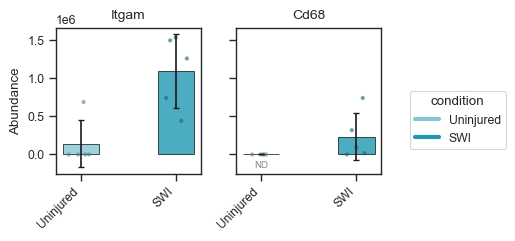

In [18]:
# showing in raw abundance y axis scale

figsize = (2, 2.5)
bar_kwargs = {"width": 0.15}

fig, ax = pdata_sc_norm.plot_abundance_boxgrid(
    namelist=["Itgam", "Cd68"],
    classes="condition",
    plot_type="bar",
    log_scale=False,
    figsize=figsize,
    bar_kwargs=bar_kwargs,
    palette=condition_color,
    nd_kwargs={"y_axes_offset": 0.03} # adjust position if needed
)
plt.show()

The same panels support **significance brackets**: pass `sig_pairs` to run pairwise tests between groups and draw p-value annotations on the plot. With exactly two conditions, `sig_pairs=True` compares them automatically.

c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\srpang\anaconda3\envs\py311-dev\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxpl

     ⚠️ [WARN] Cd68: group 'Uninjured' has no detectable abundance ('ND').
     ⚠️ [WARN] Cd68: skipping comparison 'Uninjured' vs 'SWI' — ND group(s): ['Uninjured'].


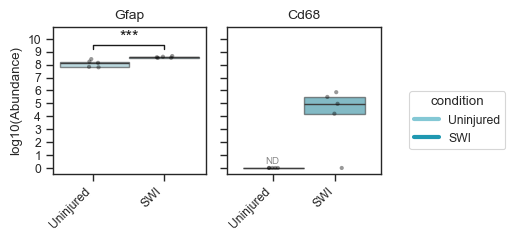

In [19]:
fig, axes = pdata_sc_norm.plot_abundance_boxgrid(
    namelist=["Gfap","Cd68"],
    classes="condition",
    plot_type="box",
    log_scale=True,
    figsize=figsize,
    sig_pairs=True,
    palette=condition_color,
    nd_kwargs={"y_log10_offset": 1.2} # adjust position of ND text
)
plt.show()

See the [Plotting tutorial — Significance brackets](plotting.md#significance-brackets) for explicit multi-group pairs, shared groups in several comparisons, and `sig_kwargs` (test method, bracket styling).

### PCA

PCA is a useful first-pass visualization for single-cell proteomics data. We can color cells either by discrete sample class or by the abundance of a selected protein.

#### 2D PCA by class

     ℹ️ [INFO] Computing PCA (force=True)...
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%


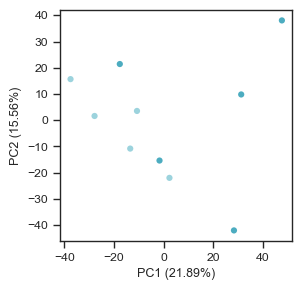

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax = scplt.plot_pca(
    ax,
    pdata_sc_norm,
    color=["condition"],
    s=20,
    alpha=.8,
    pca_params={"n_comps": 9},
    force=True,
    cmap=condition_color,
    add_ellipses=False,
)
scplt.shift_legend(ax)
plt.show()

#### 2D PCA by abundance

Linear colorbar on raw abundance (below), then `LogNorm` with `nan_color` for undetected cells (common for sparse markers such as ITGAM).

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=4.84e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%


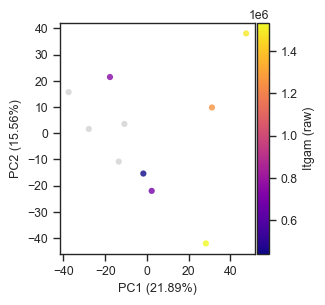

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax = scplt.plot_pca(
    ax,
    pdata_sc_norm,
    color="Itgam",
    cmap="plasma",
    s=20,
    alpha=.8,
    force=True,
)
scplt.shift_legend(ax)
plt.show()

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=4.84e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%


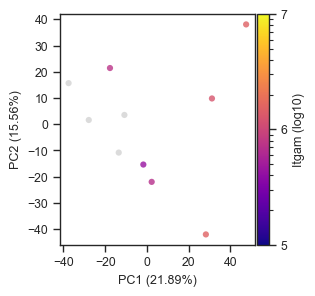

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax = scplt.plot_pca(
    ax,
    pdata_sc_norm,
    color="Itgam",
    cmap="plasma",
    colorbar_norm='log10',
    s=20,
    alpha=.8,
    force=True,
)
scplt.shift_legend(ax)
plt.show()

     ℹ️ [INFO] Computing PCA (force=True)...
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=4.84e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%


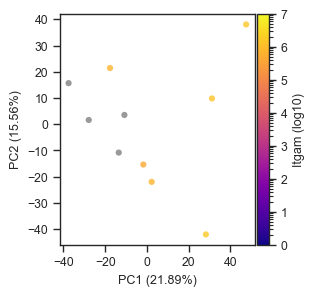

In [15]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax = scplt.plot_pca(
    ax,
    pdata_sc_norm,
    color="Itgam",
    cmap="plasma",
    colorbar_norm=mcolors.LogNorm(vmin=1, vmax=1e7),
    nan_color="grey",
    s=20,
    alpha=.8,
    force=True,
)
scplt.shift_legend(ax)
plt.show()

#### 3D PCA by class

     ℹ️ [INFO] Computing PCA (force=True)...
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%


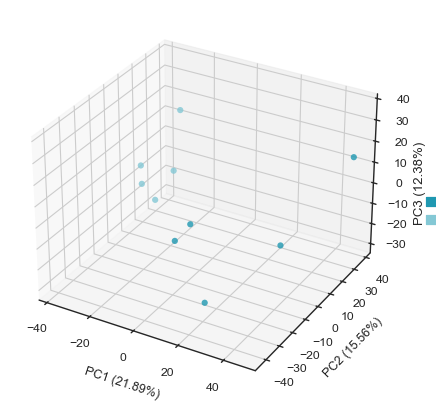

In [45]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax = scplt.plot_pca(
    ax,
    pdata_sc_norm,
    color=["condition"],
    force=True,
    plot_pc=[1, 2, 3],
    cmap=condition_color,
)
zlab = ax.get_zlabel()
ax.set_zlabel("")
ax.text2D(
    1.05,
    0.55,
    zlab,
    transform=ax.transAxes,
    rotation=90,
    ha="left",
    va="center",
    fontsize=9.5,
)
scplt.shift_legend(ax)
plt.show()

#### 3D PCA by abundance

     ℹ️ [INFO] Computing PCA (force=True)...
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%


c:\Users\srpang\anaconda3\envs\scpviz_live\Lib\site-packages\scpviz\plotting.py:1518: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap


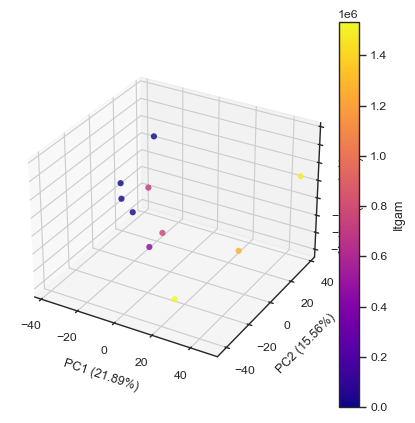

In [44]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax = scplt.plot_pca(
    ax,
    pdata_sc_norm,
    color="Itgam",
    cmap="plasma",
    force=True,
    plot_pc=[1, 2, 3],
)
zlab = ax.get_zlabel()
ax.set_zlabel("")
ax.text2D(
    1.05,
    0.55,
    zlab,
    transform=ax.transAxes,
    rotation=90,
    ha="left",
    va="center",
    fontsize=9.5,
)
scplt.shift_legend(ax)
plt.show()

### UMAP

UMAP is another useful low-dimensional embedding method for single-cell proteomics data. Compared with PCA, UMAP can better capture local neighborhood structure and is often helpful for visualizing cell-state separation or potential subpopulations.

`scpviz` includes UMAP plotting through `plot_umap()`. Internally, UMAP uses a nearest-neighbor graph (`neighbor()`) built from PCA-reduced data (`pca()` or `harmony()`), so both the neighbor settings and UMAP settings can affect the final embedding.

The main parameters can be passed through `umap_params`, including:

- `n_neighbors` - neighbor graph parameter controlling local connectivity
- `min_dist` - UMAP parameter controlling how tightly points are packed
- `metric` - neighbor graph distance metric
- `spread` - UMAP parameter controlling overall embedding scale
- `random_state` - random seed for reproducibility
- `n_pcs` - number of principal components used to build the neighbor graph

For datasets with stronger batch effects, `scpviz` also supports Harmony integration through `pdata.harmony()`. This method applies Harmony-based batch correction using `scanpy.external.pp.harmony_integrate` on PCA-reduced protein or peptide data before downstream visualization.

#### UMAP by class

UMAP calculation forced, re-calculating UMAP
🧭 [USER] Computing UMAP [protein] using layer: X
     ℹ️ n_neighbors=7 provided. Re-running neighbors with these settings before UMAP.
     🧭 Computing neighbors [protein] using layer: X
     ℹ️ Recomputing PCA for neighbor graph.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%
     ✅ Neighbors computed on X, using X_pca. Results stored in:
       • obs['distances'] (pairwise distances)
       • obs['connectivities'] (connectivity graph)
       • uns['neighbors'] (neighbor graph metadata)
     ✅ UMAP complete. Results stored in:
       • obsm['X_umap'] (UMAP coordinates)
       • uns['umap'] (UMAP settings)


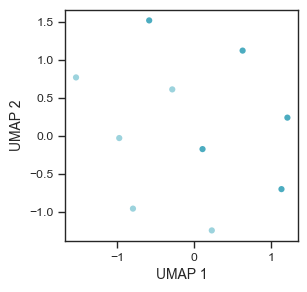

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
umap_params = {"min_dist": 0.3, "n_neighbors": 7}

ax = scplt.plot_umap(
    ax,
    pdata_sc_norm,
    color=["condition"],
    s=20,
    alpha=.8,
    force=True,
    umap_params=umap_params,
    cmap=condition_color,
)
scplt.shift_legend(ax)
plt.show()

#### UMAP by abundance

UMAP calculation forced, re-calculating UMAP
🧭 [USER] Computing UMAP [protein] using layer: X
     ℹ️ n_neighbors=7 provided. Re-running neighbors with these settings before UMAP.
     🧭 Computing neighbors [protein] using layer: X
     ℹ️ Recomputing PCA for neighbor graph.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%
     ✅ Neighbors computed on X, using X_pca. Results stored in:
       • obs['distances'] (pairwise distances)
       • obs['connectivities'] (connectivity graph)
       • uns['neighbors'] (neighbor graph metadata)
     ✅ UMAP complete. Results stored in:
       • obsm['X_umap'] (UMAP coordinates)
       • uns['umap'] (UMAP settings)


c:\Users\srpang\anaconda3\envs\scpviz_live\Lib\site-packages\scpviz\plotting.py:1518: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap


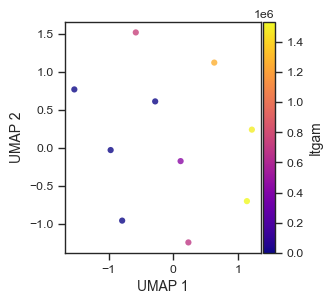

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
umap_params = {"min_dist": 0.3, "n_neighbors": 7}

ax = scplt.plot_umap(
    ax,
    pdata_sc_norm,
    color="Itgam",
    cmap="plasma",
    s=20,
    alpha=.8,
    force=True,
    umap_params=umap_params,
)
scplt.shift_legend(ax)
plt.show()

#### UMAP by abundance (log scale)

Same `LogNorm` / `nan_color` pattern on UMAP for sparse protein expression.

UMAP calculation forced, re-calculating UMAP
🧭 [USER] Computing UMAP [protein] using layer: X
     ℹ️ n_neighbors=7 provided. Re-running neighbors with these settings before UMAP.
     🧭 Computing neighbors [protein] using layer: X
     ℹ️ Recomputing PCA for neighbor graph.
     ℹ️ [INFO] Layer 'X' appears to contain non-log intensities (median=4.84e+04). PCA will proceed with z-scoring (standard practice). Optionally run pdata.log_transform() first for better low-abundance separation.
🧭 [USER] Performing PCA [protein] using layer: X, removing NaN features.
   🔸 BEFORE (samples × proteins): (10, 3192)
   🔸 AFTER  (samples × proteins): (10, 3123)
     ✅ PCA complete, fitted on X. Results stored in:
       • .prot.obsm['X_pca']
       • .prot.uns['pca'] (includes PCs, variance, variance ratio)
       • Variance explained by PC1/PC2: 21.89% , 15.56%
     ✅ Neighbors computed on X, using X_pca. Results stored in:
       • obs['distances'] (pairwise distances)
       • obs['connectivities'

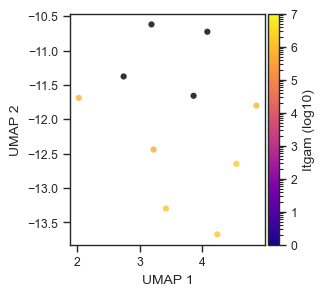

In [16]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
umap_params = {"min_dist": 0.3, "n_neighbors": 7}

ax = scplt.plot_umap(
    ax,
    pdata_sc_norm,
    color="Itgam",
    cmap="plasma",
    colorbar_norm=mcolors.LogNorm(vmin=1, vmax=1e7),
    nan_color="black",
    s=20,
    alpha=.8,
    force=True,
    umap_params=umap_params,
)
scplt.shift_legend(ax)
plt.show()

## Differential expression

Differential expression (DE) analysis can be used to identify proteins that differ between biological conditions. In this example, we compare **SWI** against **Uninjured** cells.

In [20]:
case_values = [{"condition": "SWI"}, {"condition": "Uninjured"}]

color_dict = {
    "upregulated": condition_color["SWI"],
    "downregulated": condition_color["Uninjured"],
    "not_significant": "#FFFFFF6A",
}

A common way to visualize DE results is with a **volcano plot**, which shows the relationship between **fold change** and **statistical significance**.

`scpviz` supports multiple fold-change calculation modes:

- `mean` - compare the mean abundance between groups; this is the default
- `pairwise_median` - compute fold changes across all possible sample pairs and take the median
- `pep_pairwise_median` - compute peptide-level pairwise fold changes per protein and take the median; this is similar to the approach used in Proteome Discoverer

The pairwise-based methods can sometimes be more robust to variation, but for single-cell datasets they may be less reliable if the data are too sparse.

🧭 [USER] Running differential expression [protein]
   🔸 Comparing groups: [{'condition': 'SWI'}] vs [{'condition': 'Uninjured'}]
   🔸 Group sizes: 5 vs 5 samples
   🔸 Method: ttest | Fold Change: mean | Layer: X
   🔸 P-value threshold: 0.05 | Log2FC threshold: 1
     ℹ️ [INFO] 413 proteins were not comparable (zero or NaN mean in one group).
     ✅ DE complete. Results stored in:
       • .stats["[{'condition': 'SWI'}] vs [{'condition': 'Uninjured'}]"]
       • Columns: log2fc, p_value, significance, etc.
       • Upregulated: 86 | Downregulated: 88 | Not significant: 2605


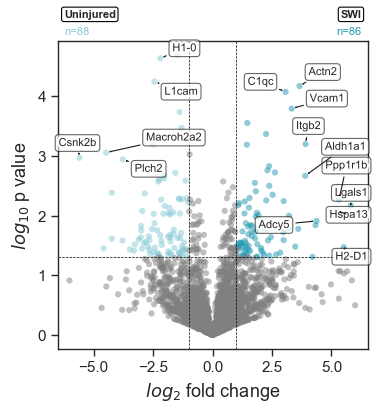

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ax, volcano_df = scplt.plot_volcano(
    ax,
    pdata_sc_norm,
    values=case_values,
    threshold=0.05,
    return_df=True,
    color=color_dict,
    fold_change_mode="mean",
    label=[10, 5],
)

ax.set_ylabel("$log_{10}$ p value", fontsize=13, labelpad=4)
ax.set_xlabel("$log_{2}$ fold change", fontsize=13, labelpad=4)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

plt.show()

Here, `label=[10, 5]` controls how many protein labels are shown on the plot from each side of the distribution. In this case, the plot will annotate the top **10** proteins on one side and **5** on the other, based on the internal ranking used for labeling.

Because single-cell data can be sparse, DE results should be interpreted with some care. In practice, it is often useful to combine DE with abundance plots, detection-rate filtering, or downstream enrichment analysis to focus on the most biologically meaningful candidates.

Access the DE results stored in `.stats` under the key shown in the output including **log₂ fold change**, **p-value**, and **significance score**.

In [22]:
pdata_sc_norm.stats["[{'condition': 'SWI'}] vs [{'condition': 'Uninjured'}]"]

,Genes,[{'condition': 'SWI'}],[{'condition': 'Uninjured'}],log2fc,p_value,test_statistic,-log10(p_value),significance_score,significance
Q91W97,Hkdc1,87520.261690,4754.490872,4.202254,0.049370,2.314127,1.306537,5.490399,upregulated
P16045,Lgals1,517396.719584,9194.245085,5.814396,0.006790,3.619273,2.168146,12.606461,upregulated
Q02105,C1qc,287442.513109,34201.408790,3.071146,0.000085,7.289030,4.071693,12.504762,upregulated
Q9D8U8,Snx5,254019.966147,48848.339896,2.378560,0.001493,4.724985,2.826074,6.721987,upregulated
P84309,Adcy5,195455.170023,9443.617446,4.371354,0.012339,3.214614,1.908736,8.343763,upregulated
...,...,...,...,...,...,...,...,...,...
Q9Z0W3,Nup160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not comparable
Q69Z26,Cntn4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not comparable
Q8C2E7,Washc5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not comparable
Q8CHU3,Epn2,0.000000,26025.371230,NaN,0.018712,-2.939931,1.727889,NaN,not comparable


### STRING enrichment

We can perform **STRING enrichment** on the sets of up- and downregulated proteins from our DE analysis. First, list the available enrichment keys:

In [52]:
pdata_sc_norm.list_enrichments()

🧭 [USER] Listing STRING enrichment status

     ℹ️ Available DE comparisons (not yet enriched):
        - SWI vs Uninjured

  🔹 To run enrichment:
      pdata.enrichment_functional(from_de=True, de_key="...")

✅ Completed STRING enrichment results:
    (none)

✅ Completed STRING PPI results:
    (none)


Since we just ran a DE analysis, the key **`SWI vs Uninjured`** is available. We can run STRING **functional enrichment** on both up- and downregulated proteins.

In [53]:
pdata_sc_norm.enrichment_functional(from_de=True, de_key="SWI vs Uninjured")

🧭 [USER] Running STRING enrichment [DE-based: [{'condition': 'SWI'}] vs [{'condition': 'Uninjured'}]]

🔹 Up-regulated proteins
     ℹ️ Found 0 cached STRING IDs. 86 need lookup.
     🌐 [API] UniProt mapped: 82 / 86
     🌐 [API] STRING mapped: 0 / 4 (missing after UniProt)
          ℹ️ Cached 82 STRING ID mappings.
   🔸 Proteins: 86 → STRING IDs: 82
   🔸 Species: 10090 | Background: None
     ✅ [OK] Enrichment complete (7.11s)
   • Access result: pdata.stats['functional']["SWI vs Uninjured_up"]["result"]
   • Plot command : pdata.plot_enrichment_svg("SWI vs Uninjured", direction="up")
   • View online  : https://string-db.org/cgi/network?identifiers=10090.ENSMUSP00000020277%0d10090.ENSMUSP00000086795%0d10090.ENSMUSP00000036747%0d10090.ENSMUSP00000105657%0d10090.ENSMUSP00000110563%0d10090.ENSMUSP00000114304%0d10090.ENSMUSP00000032492%0d10090.ENSMUSP00000028755%0d10090.ENSMUSP00000091435%0d10090.ENSMUSP00000034947%0d10090.ENSMUSP00000147928%0d10090.ENSMUSP00000052912%0d10090.ENSMUSP000000

Once enrichment is complete, you can visualize the **Gene Ontology (Biological Process)** results:


🧭 [USER] Fetching STRING SVG for key 'SWI vs Uninjured_down' (n=84)...


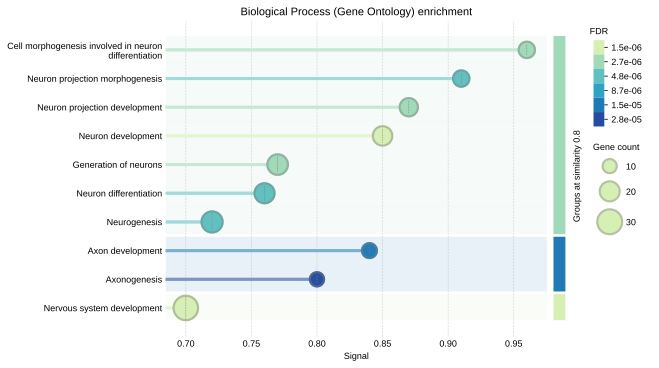

In [54]:
pdata_sc_norm.plot_enrichment_svg("SWI vs Uninjured", direction="down")

!!! note
    Refer to the [Enrichment](enrichment.md) tutorial for details on additional STRING features such as **PPI networks**, **GSEA**, and **combined enrichment-PPI analyses**.

## Using scanpy

`scpviz` is designed to work well with external single-cell analysis tools. In particular, the `.prot` and `.pep` attributes are standard `AnnData` objects, so once the data are prepared, they can be used directly with functions from packages such as **scanpy**.

Before using `scanpy`, it is important to clean the data matrix because `scanpy` generally expects **0 values rather than `NaN`s** in `.X`. If `NaN`s are left in place, many `scanpy` functions will raise errors.


In [23]:
pdata_sc_norm.clean_X()

🧭 [USER] Cleaning prot data: making scanpy compatible, replacing NaNs with 0 in .X.
     ℹ️ [INFO] Backed up .X to .layers['X_preclean']
     ✅ [OK] Cleaned .X: replaced 690 NaNs with 0.


Once cleaned, you can work directly with `pdata_sc_norm.prot` or `pdata_sc_norm.pep`, depending on whether you want to analyze protein-level or peptide-level data.

For example, the protein-level matrix can be passed directly into a standard `scanpy` workflow:

In [40]:
adata_prot = pdata_sc_norm.prot

sc.pp.scale(adata_prot)
sc.tl.pca(adata_prot, svd_solver='arpack')
sc.pp.neighbors(adata_prot)

sc.tl.leiden(
    adata_prot, 
    flavor="leidenalg",  
    n_iterations=2,
    resolution=2,
)

c:\Users\srpang\anaconda3\envs\py311\Lib\site-packages\scanpy\preprocessing\_pca.py:198: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  version.parse(ad.__version__) < version.parse("0.9")
c:\Users\srpang\anaconda3\envs\py311\Lib\site-packages\scanpy\neighbors\__init__.py:408: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


In [26]:
sc.tl.umap(adata_prot)

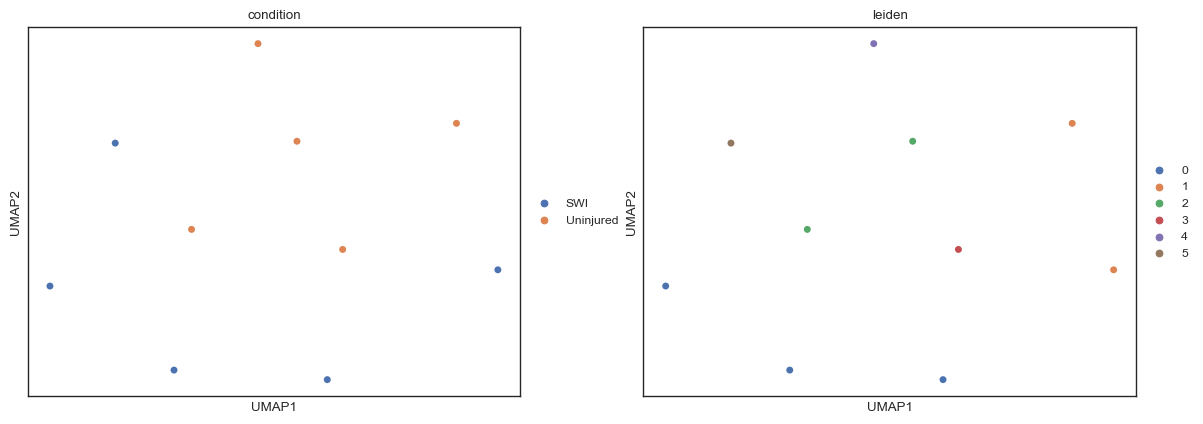

In [41]:
sc.pl.umap(adata_prot, color=["condition", "leiden"],size=100)

c:\Users\srpang\anaconda3\envs\py311\Lib\site-packages\scanpy\tools\_dendrogram.py:123: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in adata.obs_keys():
c:\Users\srpang\anaconda3\envs\py311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:106: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if "log1p" in adata.uns_keys() and adata.uns["log1p"].get("base") is not None:
c:\Users\srpang\anaconda3\envs\py311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\srpang\anaconda3\envs\py311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats

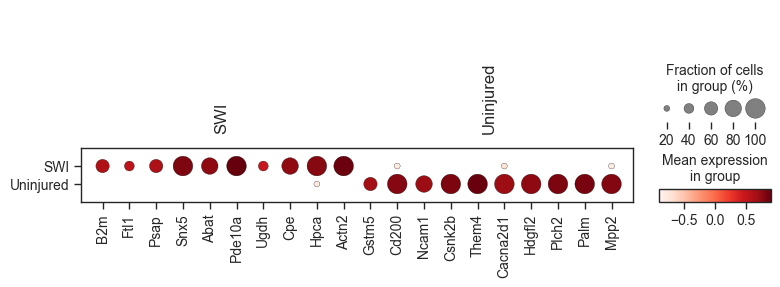

In [34]:
sc.tl.dendrogram(adata_prot, groupby='condition')

sc.tl.rank_genes_groups(adata_prot, groupby="condition", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata_prot, n_genes=10, swap_axes=False, gene_symbols='Genes')

This makes it straightforward to use `scpviz` for preprocessing and proteomics-specific handling, while still taking advantage of the broader single-cell ecosystem for clustering, neighborhood graph construction, marker ranking, and visualization.

!!! note
    See the [scanpy tutorials](https://scanpy.readthedocs.io/en/stable/tutorials/index.html) for additional examples and workflows that can be applied directly to `pdata_sc_norm.prot` or `pdata_sc_norm.pep`.

## Next steps

Further analyses that can be performed on single-cell proteomics data include:

- clustering using scanpy or other single-cell frameworks  
- trajectory or pseudotime analysis  
- pathway enrichment of differentially expressed proteins  
- integration with transcriptomic single-cell datasets

Because `scpviz` stores data in standard AnnData objects, it can be easily combined with tools from the broader single-cell ecosystem.